# Iowa seasonal risk hours

Count individual hourly observations for six fixed-capacity portfolios, five 20-year periods, four Iowa-local seasons, and two stress metrics.

**Inputs:** the released TaiESM1 Iowa scenario-metrics Parquet file for 2000–2099, using raw net load and renewable-equivalent capacity factor. Each scenario has 8,760 timestamps per year, with leap-day hours omitted.

**Requirements:** extract the TaiESM1 Zenodo collection into `data_inputs/`.

**Outputs:** a 240-row CSV and six portfolio figures under `data_outputs/analysis/state_seasonal_risk_hours/`, with the figures also embedded below. Planning periods use the UTC year; seasons use the local month in `America/Chicago`.

Run the code cells from top to bottom. See the [setup instructions](../../README.md#quick-start).

## Setup

In [1]:
from pathlib import Path
from zoneinfo import ZoneInfo

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

OUTPUT_DIR = Path("../../data_outputs/analysis/state_seasonal_risk_hours").resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

METRICS_PATH = Path(
    "../../data_inputs/taiesm1_historical_ssp245_v022_2000_2099/state_scenario_metrics/IA_taiesm1_historical_ssp245_v022_2000_2099_scenario_metrics.parquet"
).resolve()

SCENARIOS = pd.DataFrame(
    [
        ("installed_2024", "2024 EIA-860 Operable"),
        ("split_w100_s00", "100W / 0S"),
        ("split_w75_s25", "75W / 25S"),
        ("split_w50_s50", "50W / 50S"),
        ("split_w25_s75", "25W / 75S"),
        ("split_w00_s100", "0W / 100S"),
    ],
    columns=["scenario", "scenario_label"],
)

PLANNING_PERIODS = pd.DataFrame(
    [
        ("2000_2019", 2000, 2019),
        ("2020_2039", 2020, 2039),
        ("2040_2059", 2040, 2059),
        ("2060_2079", 2060, 2079),
        ("2080_2099", 2080, 2099),
    ],
    columns=["planning_period", "start_year", "end_year"],
)

SEASON_ORDER = ["Dec/Jan/Feb", "Mar/Apr/May", "Jun/Jul/Aug", "Sep/Oct/Nov"]
SEASON_LABELS = {
    "Dec/Jan/Feb": "DJF (Winter)",
    "Mar/Apr/May": "MAM (Spring)",
    "Jun/Jul/Aug": "JJA (Summer)",
    "Sep/Oct/Nov": "SON (Autumn)",
}
SEASON_COLORS = {
    "Dec/Jan/Feb": "tab:blue",
    "Mar/Apr/May": "tab:orange",
    "Jun/Jul/Aug": "tab:green",
    "Sep/Oct/Nov": "tab:red",
}
MONTH_TO_SEASON = {
    12: "Dec/Jan/Feb",
    1: "Dec/Jan/Feb",
    2: "Dec/Jan/Feb",
    3: "Mar/Apr/May",
    4: "Mar/Apr/May",
    5: "Mar/Apr/May",
    6: "Jun/Jul/Aug",
    7: "Jun/Jul/Aug",
    8: "Jun/Jul/Aug",
    9: "Sep/Oct/Nov",
    10: "Sep/Oct/Nov",
    11: "Sep/Oct/Nov",
}
PERIOD_ORDER = PLANNING_PERIODS["planning_period"].tolist()
assert METRICS_PATH.is_file()

# Shared presentation defaults; data values and plot limits are set below.
plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.titleweight": "normal",
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "legend.frameon": False,
        "grid.color": "#d1d5db",
        "grid.linewidth": 0.7,
        "grid.alpha": 0.65,
        "figure.titlesize": 16,
        "figure.titleweight": "bold",
    }
)

## Step 1: Read and check hourly inputs

Require six portfolios, complete no-leap hourly coverage, and unique timestamps within each portfolio.

In [2]:
NET_LOAD_STRESS_QUANTILE = 0.95
RENEWABLE_CF_STRESS_THRESHOLD = 0.10
STRESS_METRICS = pd.DataFrame(
    [
        ("net_load_p95", "Net load at or above pooled P95"),
        ("renew_cf_10pct", "Renewable-equivalent CF at or below 10%"),
    ],
    columns=["stress_metric", "stress_metric_label"],
)

hourly = pd.read_parquet(
    METRICS_PATH,
    columns=["time_utc", "scenario", "net_load_mw__raw", "renew_cf_equiv"],
)
hourly["time_utc"] = pd.to_datetime(hourly["time_utc"], utc=True)
scenario_hours = hourly.groupby("scenario").size()
assert set(scenario_hours.index) == set(SCENARIOS["scenario"])
assert scenario_hours.eq(100 * 8760).all()
assert not hourly.duplicated(["scenario", "time_utc"]).any()
assert not hourly[["net_load_mw__raw", "renew_cf_equiv"]].isna().any().any()

## Step 2: Define thresholds and assign periods and seasons

The net-load P95 uses all hours in all six mixes over 2000–2099. The renewable threshold is an absolute equivalent CF of 10%. Conditions are inclusive. Planning years use UTC; seasons use Iowa local time.

In [3]:
net_load_p95_mw = float(hourly["net_load_mw__raw"].quantile(NET_LOAD_STRESS_QUANTILE))
hourly["planning_period"] = pd.NA
utc_year = hourly["time_utc"].dt.year
for period in PLANNING_PERIODS.itertuples(index=False):
    mask = utc_year.between(period.start_year, period.end_year)
    hourly.loc[mask, "planning_period"] = period.planning_period

local_time = hourly["time_utc"].dt.tz_convert(ZoneInfo("America/Chicago"))
hourly["season"] = local_time.dt.month.map(MONTH_TO_SEASON).to_numpy()
assert not hourly[["planning_period", "season"]].isna().any().any()

## Step 3: Count stress hours

Count each qualifying hour, fill missing combinations with zero, and check that grouped counts preserve the direct totals.

In [4]:
masks = {
    "net_load_p95": hourly["net_load_mw__raw"].ge(net_load_p95_mw),
    "renew_cf_10pct": hourly["renew_cf_equiv"].le(RENEWABLE_CF_STRESS_THRESHOLD),
}
rows = []
direct_totals = {}
for metric, mask in masks.items():
    direct_totals[metric] = int(mask.sum())
    qualifying_hours = hourly.loc[mask]
    grouped = qualifying_hours.groupby(
        ["scenario", "planning_period", "season"], as_index=False
    ).size()
    grouped = grouped.rename(columns={"size": "stress_hours"})
    grouped["stress_metric"] = metric
    rows.append(grouped)

complete_index = pd.MultiIndex.from_product(
    [SCENARIOS["scenario"], STRESS_METRICS["stress_metric"], PERIOD_ORDER, SEASON_ORDER],
    names=["scenario", "stress_metric", "planning_period", "season"],
)
# Fill every portfolio/metric/period/season combination, including zero counts.
summary = pd.concat(rows, ignore_index=True)
summary = summary.set_index(["scenario", "stress_metric", "planning_period", "season"])
stress_hours = summary["stress_hours"].reindex(complete_index, fill_value=0)
stress_hours = stress_hours.astype("int64").rename("stress_hours")
summary = stress_hours.reset_index()
summary = summary.merge(SCENARIOS, on="scenario", validate="many_to_one")
summary = summary.merge(STRESS_METRICS, on="stress_metric", validate="many_to_one")
summary = summary[
    [
        "scenario",
        "scenario_label",
        "stress_metric",
        "stress_metric_label",
        "planning_period",
        "season",
        "stress_hours",
    ]
]
assert len(summary) == 6 * 5 * 4 * 2 == 240
for metric, total in direct_totals.items():
    assert int(summary.loc[summary["stress_metric"].eq(metric), "stress_hours"].sum()) == total

## Step 4: Save and inspect the summary

Write all 240 rows at full precision, then format a small preview for reading.

In [5]:
summary.to_csv(OUTPUT_DIR / "iowa_seasonal_risk_hours.csv", index=False)
thresholds = pd.DataFrame(
    [
        {
            "metric": "net_load_p95",
            "condition": f"net_load_mw__raw >= {net_load_p95_mw:.6f} MW",
            "basis": "All mixes, all 2000–2099 hours",
        },
        {
            "metric": "renew_cf_10pct",
            "condition": "renew_cf_equiv <= 0.10",
            "basis": "Absolute equivalent capacity factor",
        },
    ]
)
SCENARIO_LABELS = {
    "installed_2024": "Installed 2024",
    "split_w00_s100": "0% wind / 100% solar",
    "split_w25_s75": "25% wind / 75% solar",
    "split_w50_s50": "50% wind / 50% solar",
    "split_w75_s25": "75% wind / 25% solar",
    "split_w100_s00": "100% wind / 0% solar",
}

STRESS_METRIC_LABELS = {
    "net_load_p95": "Net load ≥ shared P95",
    "renew_cf_10pct": "Renewable-equivalent CF ≤ 10%",
}
# Format views only; the complete CSV above retains its original labels and row order.
threshold_preview = thresholds.replace({"metric": STRESS_METRIC_LABELS})
threshold_preview = threshold_preview.rename(
    columns={
        "metric": "Stress metric",
        "condition": "Condition",
        "basis": "Threshold population",
    }
)
display(threshold_preview.style.hide(axis="index"))
print(
    f"Wrote {len(summary):,} rows: 6 portfolios × 5 periods × 4 seasons × 2 metrics.\n  {(OUTPUT_DIR / 'iowa_seasonal_risk_hours.csv').as_posix()}"
)
print("Preview: 2000–2019 UTC planning years · Dec/Jan/Feb in America/Chicago.")
preview_mask = summary["planning_period"].eq("2000_2019") & summary["season"].eq("Dec/Jan/Feb")
preview = summary.loc[preview_mask, ["scenario", "stress_metric", "stress_hours"]]
preview = preview.set_index("scenario").loc[list(SCENARIO_LABELS)]
preview = preview.rename(
    index=SCENARIO_LABELS,
    columns={
        "stress_metric": "Stress metric",
        "stress_hours": "Stress hours",
    },
)
preview = preview.rename_axis("Portfolio")
preview = preview.replace({"Stress metric": STRESS_METRIC_LABELS})
display(preview.style.format({"Stress hours": "{:,d}"}))
del hourly

Stress metric,Condition,Threshold population
Net load ≥ shared P95,net_load_mw__raw >= 6011.157414 MW,"All mixes, all 2000–2099 hours"
Renewable-equivalent CF ≤ 10%,renew_cf_equiv <= 0.10,Absolute equivalent capacity factor


Wrote 240 rows: 6 portfolios × 5 periods × 4 seasons × 2 metrics.
  ../../data_outputs/analysis/state_seasonal_risk_hours/iowa_seasonal_risk_hours.csv
Preview: 2000–2019 UTC planning years · Dec/Jan/Feb in America/Chicago.


,Stress metric,Stress hours
Portfolio,,
Installed 2024,Net load ≥ shared P95,"1,478"
Installed 2024,Renewable-equivalent CF ≤ 10%,"6,376"
0% wind / 100% solar,Net load ≥ shared P95,"14,863"
0% wind / 100% solar,Renewable-equivalent CF ≤ 10%,"31,921"
25% wind / 75% solar,Net load ≥ shared P95,"2,300"
25% wind / 75% solar,Renewable-equivalent CF ≤ 10%,"12,009"
50% wind / 50% solar,Net load ≥ shared P95,"1,334"
50% wind / 50% solar,Renewable-equivalent CF ≤ 10%,"7,294"
75% wind / 25% solar,Net load ≥ shared P95,"1,108"


## Step 5: Plot seasonal risk hours

Use one panel per stress metric and one color per local season.

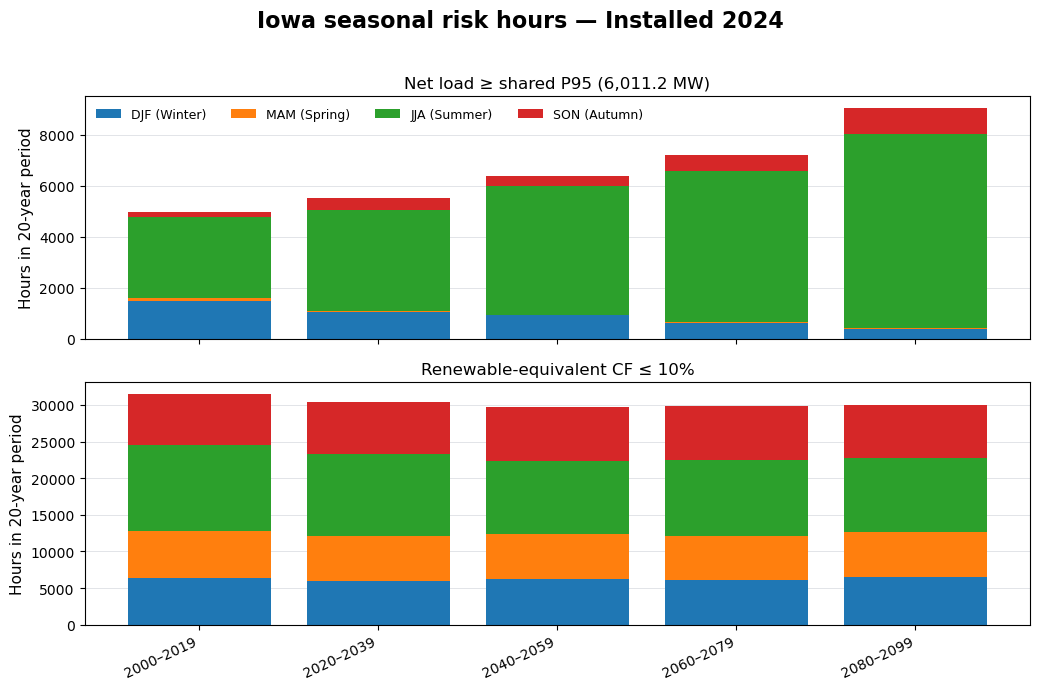

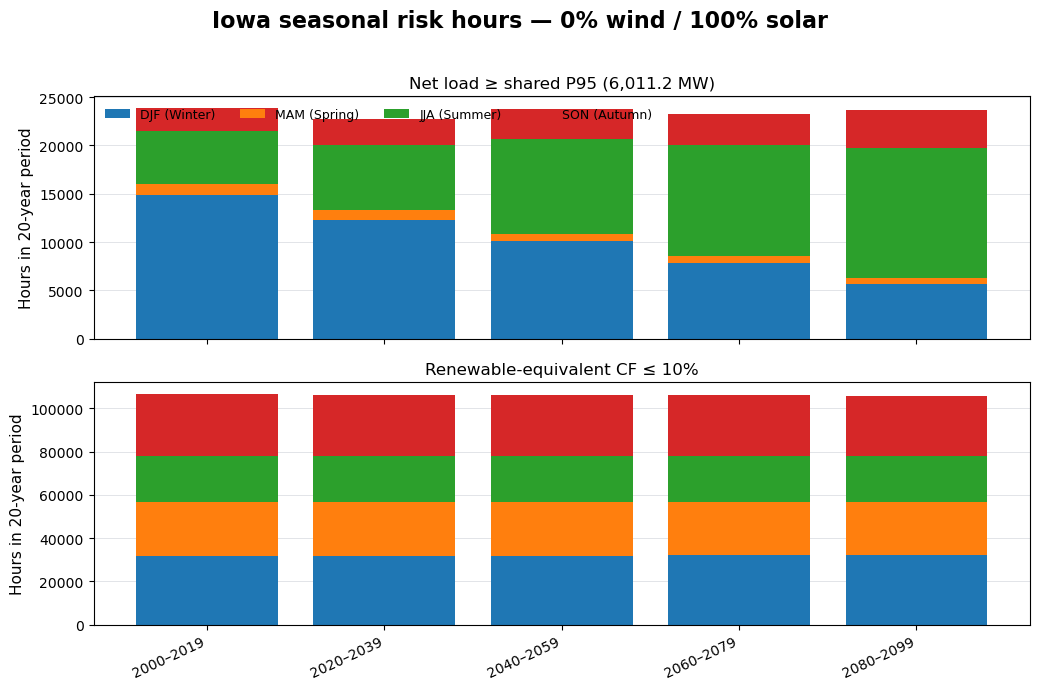

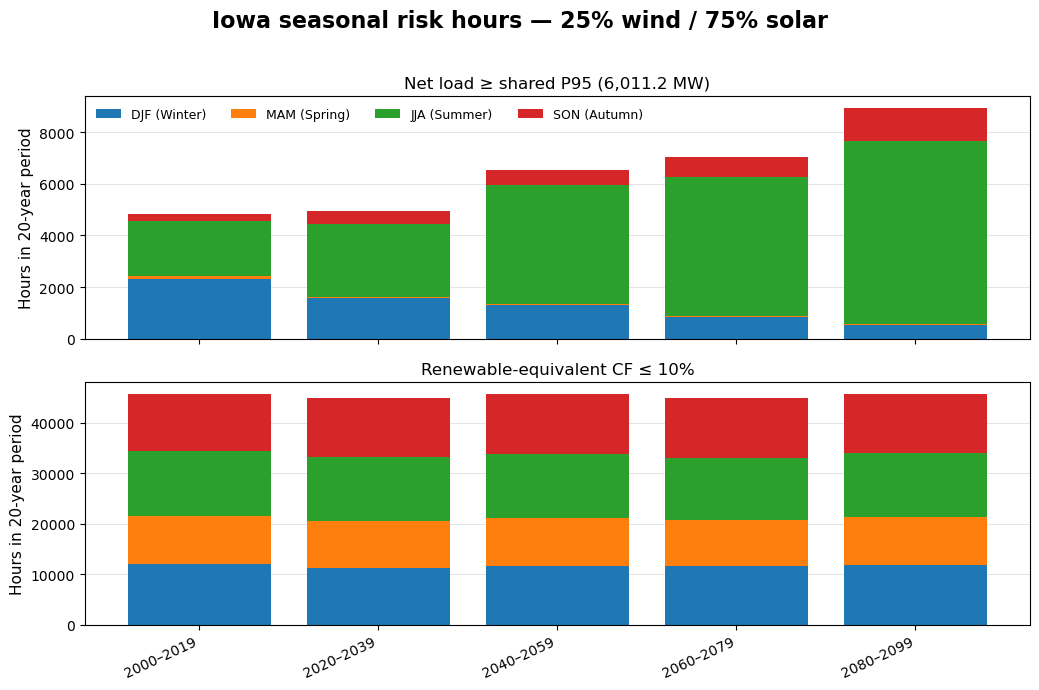

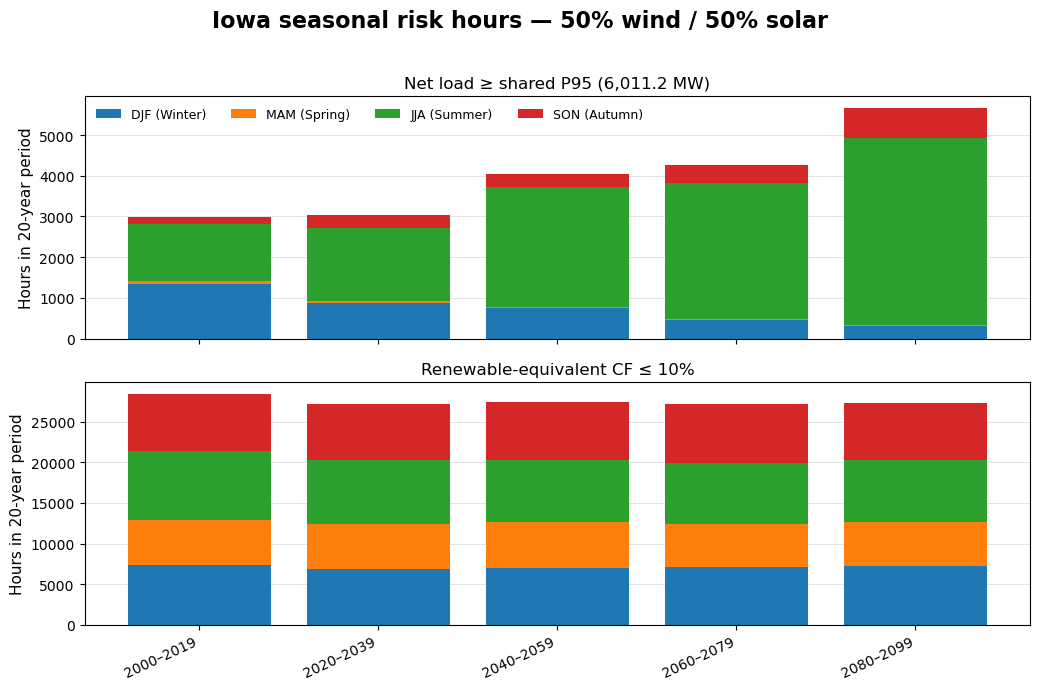

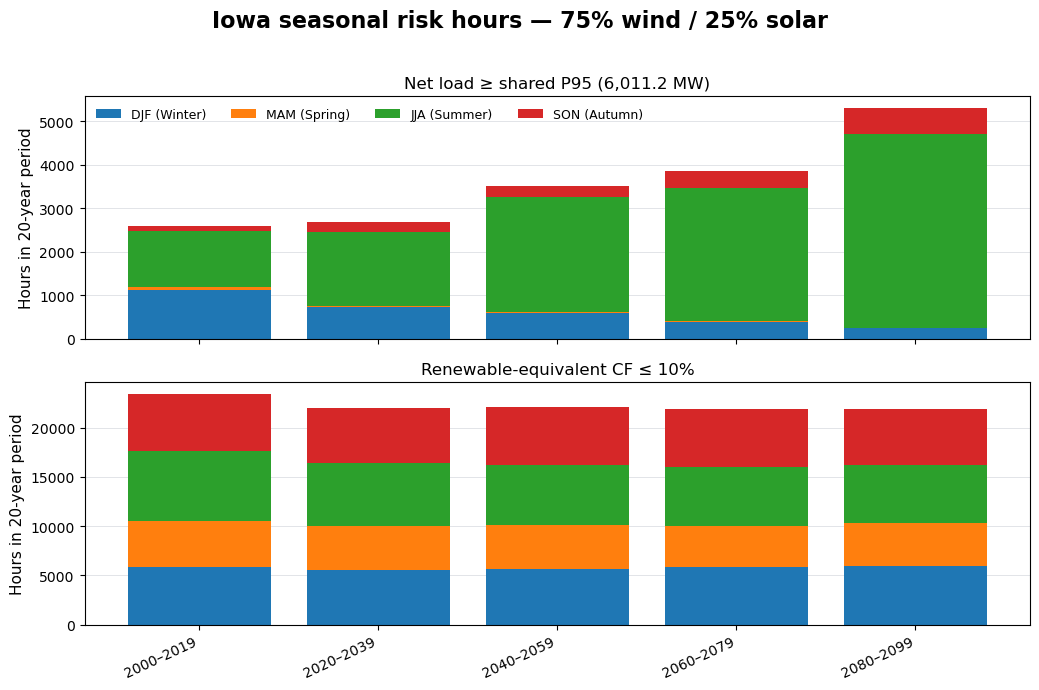

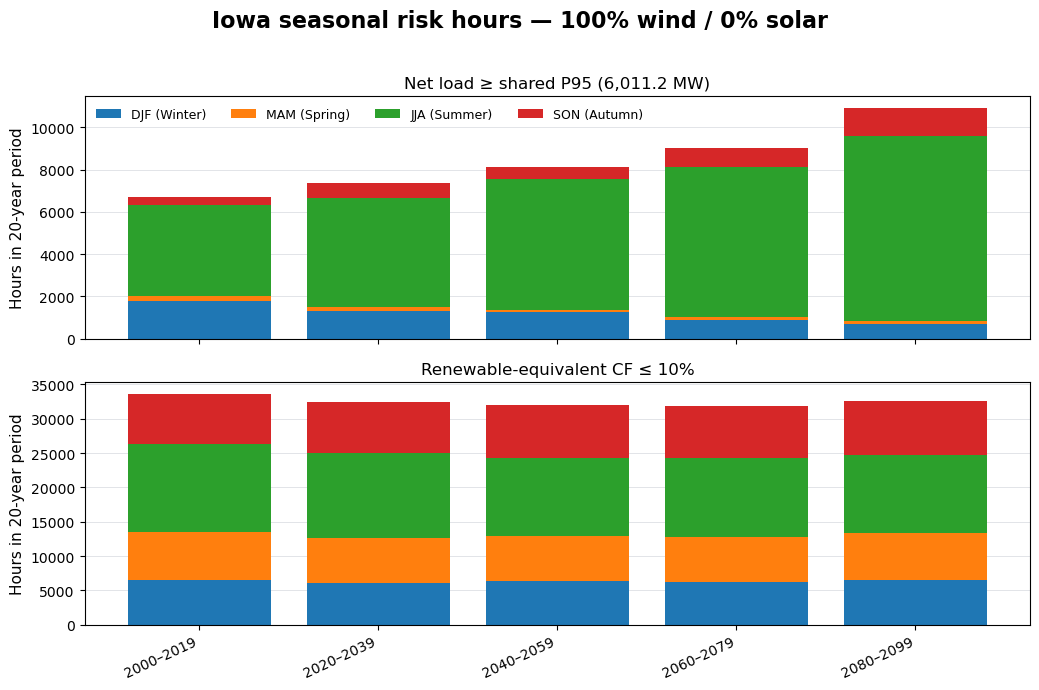

Wrote 6 portfolio figures: ../../data_outputs/analysis/state_seasonal_risk_hours


In [6]:
titles = {
    "net_load_p95": f"Net load ≥ shared P95 ({net_load_p95_mw:,.1f} MW)",
    "renew_cf_10pct": "Renewable-equivalent CF ≤ 10%",
}
x = np.arange(len(PERIOD_ORDER))
period_labels = [period.replace("_", "–") for period in PERIOD_ORDER]
plot_paths = []

for scenario in SCENARIO_LABELS:
    scenario_rows = summary[summary["scenario"].eq(scenario)]
    fig, axes = plt.subplots(2, 1, figsize=(10.5, 7.0), sharex=True)
    for axis, metric in zip(axes, STRESS_METRICS["stress_metric"]):
        matrix = (
            scenario_rows[scenario_rows["stress_metric"].eq(metric)]
            .pivot(index="planning_period", columns="season", values="stress_hours")
            .reindex(index=PERIOD_ORDER, columns=SEASON_ORDER, fill_value=0)
        )
        assert matrix.shape == (5, 4) and not matrix.isna().any().any()
        bottom = np.zeros(5)
        for season in SEASON_ORDER:
            values = matrix[season].to_numpy(dtype=float)
            axis.bar(
                x, values, bottom=bottom, color=SEASON_COLORS[season], label=SEASON_LABELS[season]
            )
            bottom += values
        axis.set_title(titles[metric])
        axis.set_ylabel("Hours in 20-year period")
        axis.grid(axis="y", color="#d1d5db", linewidth=0.7, alpha=0.65)
        axis.set_axisbelow(True)
    axes[-1].set_xticks(x, period_labels, rotation=25, ha="right")
    axes[0].legend(frameon=False, ncol=4, fontsize=9, loc="upper left")
    fig.suptitle(
        f"Iowa seasonal risk hours — {SCENARIO_LABELS[scenario]}",
        fontsize=16,
        fontweight="bold",
    )
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    output_path = OUTPUT_DIR / f"iowa_{scenario}_seasonal_risk_hours.png"
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plot_paths.append(output_path)
    plt.show()
    plt.close(fig)

assert len(plot_paths) == 6 and all(path.stat().st_size > 0 for path in plot_paths)
print(f"Wrote {len(plot_paths)} portfolio figures: {OUTPUT_DIR.as_posix()}")

## Interpretation

The bars show total qualifying hours in each 20-year period. Net-load stress uses one P95 threshold shared across all six portfolios and the full century; renewable stress uses an absolute 10% equivalent-CF threshold. These are hourly counts, without the event catalog’s gap bridging.